In [17]:
from sklearn.datasets import make_swiss_roll
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.datasets import make_circles
from  sklearn.datasets import make_blobs

import matplotlib.pyplot as plt
import numpy as np


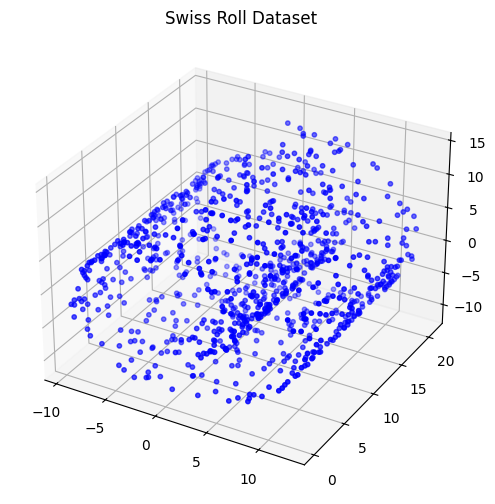

In [18]:
n_samples = 1000
noise = 0.05
X, _ = make_swiss_roll(n_samples=n_samples,
                       noise=noise)
#  3D qeyri-xətti manifold yaradır


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111,  # 1 sətir, 1 sütun, 1-ci qrafik
                     projection='3d') # 3D ox sistemi
ax.scatter(X[:, 0],# → x koordinatları
           X[:, 1], #→ y koordinatları
           X[:, 2],#→ z koordinatları
           c='blue', #  mavi  noqteler
           s=10)  # marker olcusu
plt.title("Swiss Roll Dataset")
plt.show()

In [19]:
# PCA obyektinin yaradılması
# Məqsəd: 3 ölçünü 2 əsas komponentə proyeksiya etmək
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)
X_reduced
# fit → kovarians matrisini və əsas istiqamətləri hesablayır
# transform → məlumatı həmin istiqamətlərə proyeksiya edir
# Nəticə: (1000 × 2) ölçülü yeni təmsil

array([[  4.89088689, -10.4962383 ],
       [  3.16709263,  -5.93969933],
       [ -3.77376422,   3.39573965],
       ...,
       [ -4.32869728,   4.92220462],
       [ -8.71207793,  -6.93353281],
       [  0.95777806,   9.41135975]], shape=(1000, 2))

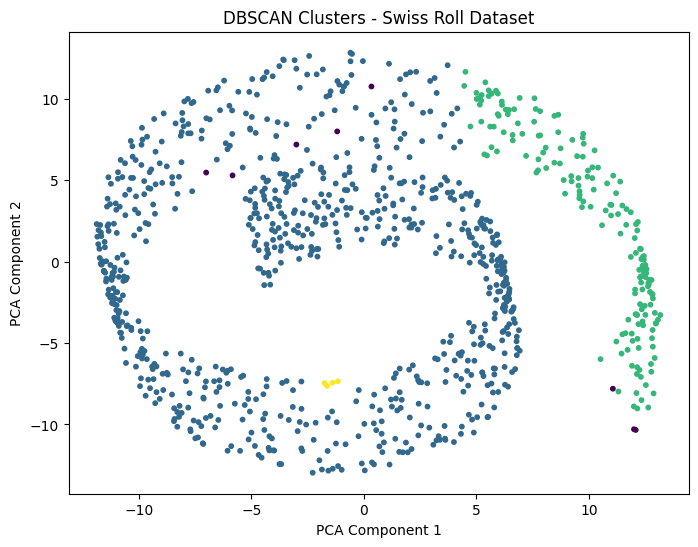

In [20]:
eps = 1.0         #  qonşuluq radiusu
min_samples = 4  # core nöqtə üçün minimal qonşu sayı
model = DBSCAN(eps=eps,
               min_samples=min_samples)

labels = model.fit_predict(X_reduced)
# fit → sıxlıq strukturlarını tapır
# predict → hər nöqtəyə klaster etiketi verir


plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0],
            X_reduced[:, 1],
            c=labels,  #  rənglər klaster ID-lərə görə
            cmap='viridis', # rəng xəritəsi
            s=10)  # marker ölçüsü
plt.title("DBSCAN Clusters - Swiss Roll Dataset")
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


In [21]:
import umap
import hdbscan

umap_model = umap.UMAP(
    n_neighbors=15,      # lokal struktur balansı
    min_dist=0.1,        # sıxlıq qorunması
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X)


c:\Users\USER\envs\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

In [ ]:
hdb = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10
)

labels_umap = hdb.fit_predict(X_umap)

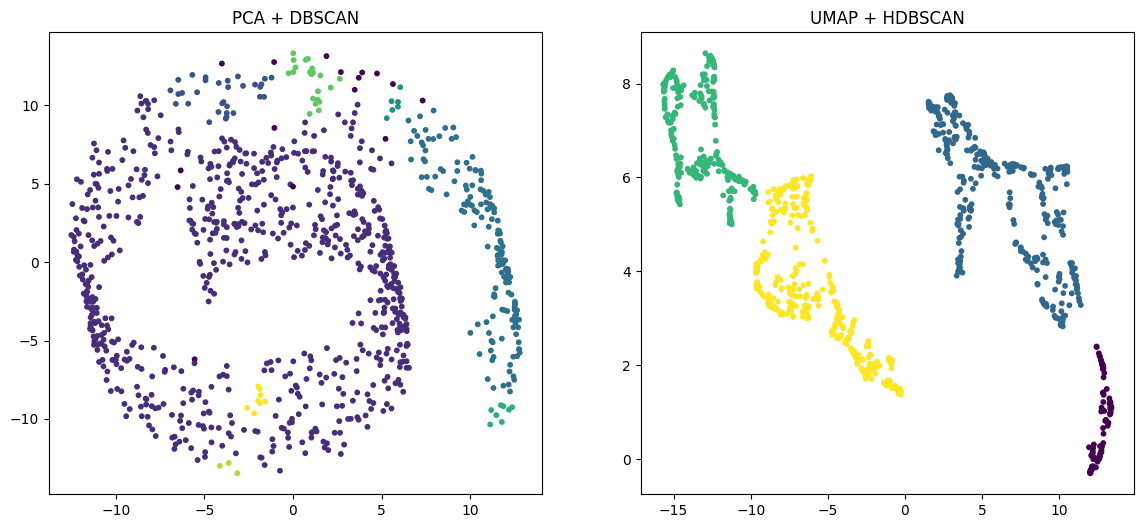

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA nəticəsi
axes[0].scatter(X_reduced[:, 0],
                X_reduced[:, 1],
                c=labels,
                  cmap='viridis',
                   s=10)
axes[0].set_title("PCA + DBSCAN")

# UMAP nəticəsi
axes[1].scatter(X_umap[:, 0],
                 X_umap[:, 1],
                   c=labels_umap,
                     cmap='viridis',
                       s=10)
axes[1].set_title("UMAP + HDBSCAN")

plt.show()


## MAKE CIRCLES 

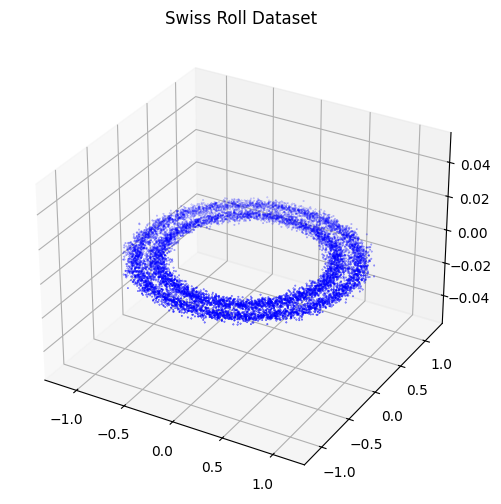

In [22]:
n_samples = 10000
noise = 0.05
X, _ = make_circles(n_samples=n_samples,
                       noise=noise)


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111,  # 1 sətir, 1 sütun, 1-ci qrafik
                     projection='3d') # 3D ox sistemi
ax.scatter(X[:, 0],# → x koordinatları
           X[:, 1], #→ y koordinatları
         #   X[:, 2],#→ z koordinatları
           c='blue', #  mavi  noqteler
           s=0.1)  # marker olcusu
plt.title("Swiss Roll Dataset")
plt.show()

In [ ]:
pca = PCA(n_components=2,)
X_pca = pca.fit_transform(X)
X_pca

array([[ 0.63868892,  0.48425954],
       [-0.20502365, -0.77808569],
       [ 0.57729197,  0.58656036],
       ...,
       [-0.6501607 ,  0.48988515],
       [ 0.65492984,  0.80973315],
       [-0.99223491,  0.1525191 ]], shape=(10000, 2))

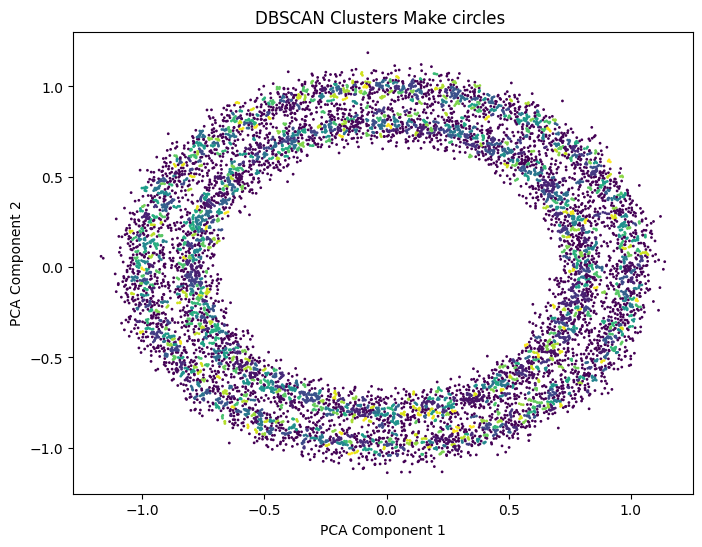

In [39]:
eps = 0.01      #  qonşuluq radiusu
min_samples = 3 # core nöqtə üçün minimal qonşu sayı
model = DBSCAN(eps=eps,
               min_samples=min_samples)
labels = model.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0],
            X_pca[:, 1],
            c=labels,  #  rənglər klaster ID-lərə görə
            cmap='viridis', # rəng xəritəsi
            s=1)  # marker ölçüsü
plt.title("DBSCAN Clusters Make circles ")
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

## MAKE BLOBS

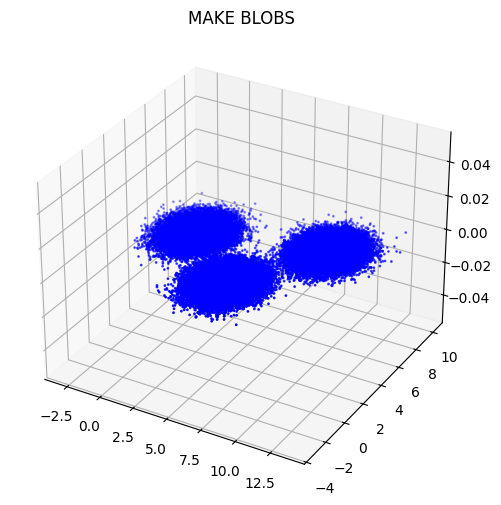

In [50]:
n_samples = 100000
noise =  3000 
X, _ = make_blobs(n_samples=n_samples, centers=3, n_features=10,
                  random_state=0)


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111,  # 1 sətir, 1 sütun, 1-ci qrafik
                     projection='3d') # 3D ox sistemi
ax.scatter(X[:, 0],# → x koordinatları
           X[:, 1], #→ y koordinatları
        #    X[:, 2],#→ z koordinatları
           c='blue', #  mavi  noqteler
           s=1)  # marker olcusu
plt.title("MAKE BLOBS")
plt.show()

In [51]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_pca

array([[  2.66821333,  -8.61699675],
       [-11.17826615,   4.23146052],
       [-11.5119488 ,   2.82379305],
       ...,
       [  9.58527094,   6.03475527],
       [  8.61484749,   4.499722  ],
       [-11.8059429 ,   1.83456662]], shape=(100000, 2))

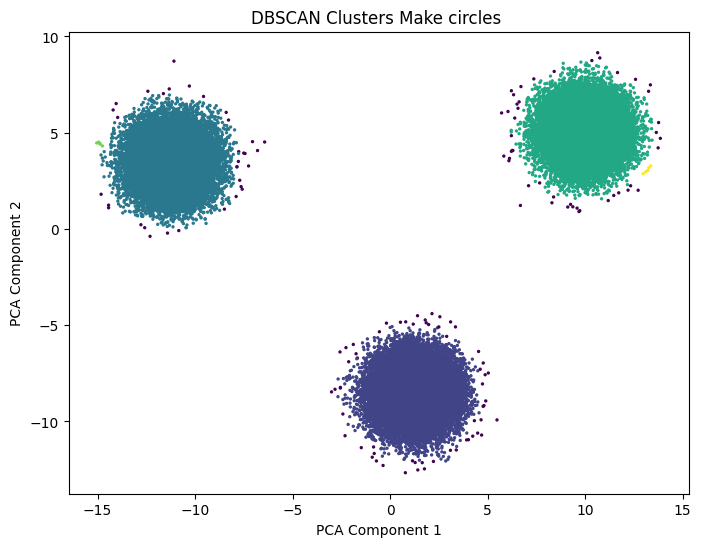

In [54]:
eps = 0.3      #  qonşuluq radiusu
min_samples = 5 # core nöqtə üçün minimal qonşu sayı
model = DBSCAN(eps=eps,
               min_samples=min_samples)
labels = model.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0],
            X_pca[:, 1],
            # X_pca[:, 2],
            # X_pca[:, 3],
            c=labels,  #  rənglər klaster ID-lərə görə
            cmap='viridis', # rəng xəritəsi
            s=2   # marker ölçüsü
            )
plt.title("DBSCAN Clusters Make circles ")
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()